# MODELO DE REGRESSÃO LINEAR PELA EQUAÇÃO NORMAL

**Instituição:** Universidade de Brasília

**Disciplina:** FGA0083 - Aprendizado de Máquina

**Professor:** Dr. Sergio Antônio Andrade de Freitas

---

## 1. INTRODUÇÃO

Este notebook demonstra a implementação de um modelo de Regressão Linear Simples a partir do cálculo direto de seus coeficientes, utilizando a **Equação Normal**. Diferentemente de métodos iterativos como o Gradiente Descendente, a Equação Normal oferece uma solução analítica para encontrar os parâmetros ótimos do modelo.

O processo será ilustrado com um conjunto de dados sintético que correlaciona o tempo de estudo de um aluno com a sua respectiva nota, demonstrando um fluxo de trabalho completo, desde a geração dos dados até a predição e visualização.

---

## 2. METODOLOGIA

A construção do modelo é realizada em uma série de passos bem definidos, que incluem a importação de bibliotecas, a geração de dados e o cálculo dos coeficientes do modelo.

### 2.1. Importação das bibliotecas

In [2]:
import numpy as np
import matplotlib.pyplot as plt

print("Bibliotecas importadas.")

Bibliotecas importadas.


### 2.2. Passo 1: Geração de dados sintéticos

Para a análise, são gerados 100 pontos de dados que simulam uma relação linear entre o tempo de estudo e a nota obtida. Um ruído gaussiano é adicionado para simular a variabilidade encontrada em dados do mundo real.

In [3]:
# Semente para garantir a reprodutibilidade dos resultados
np.random.seed(42)

# Geração da variável independente: tempo de estudo entre 0 e 10 horas
tempo_de_estudo = 10 * np.random.rand(100, 1)

# Parâmetros da relação linear subjacente
nota_base = 5.0     # Intercepto (nota teórica com 0 horas de estudo)
nota_por_hora = 0.5 # Coeficiente angular (ganho de nota por hora)

# Geração da variável dependente: notas simuladas com ruído
notas = nota_base + nota_por_hora * tempo_de_estudo + np.random.randn(100, 1)

print("Conjunto de dados sintético criado.")

Conjunto de dados sintético criado.


### 2.3. Passo 2: Cálculo dos coeficientes com a equação normal

Os coeficientes ótimos do modelo (parâmetros $ \theta $) são calculados diretamente pela Equação Normal, cuja fórmula é:

$ \hat{\theta} = (X^T X)^{-1} X^T y $

Para isso, adiciona-se uma coluna de uns à matriz de *features* `X` para representar o termo de interceptação ($ \theta_0 $).

In [4]:
# Adiciona o termo de interceptação x0 = 1 a cada instância
X_b = np.c_[np.ones((100, 1)), tempo_de_estudo]

# Calcula os coeficientes ótimos usando a Equação Normal
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(notas)

print(f"Coeficientes calculados (theta): \nIntercepto (theta_0) = {theta_best[0][0]:.4f}\nCoeficiente angular (theta_1) = {theta_best[1][0]:.4f}")

Coeficientes calculados (theta): 
Intercepto (theta_0) = 5.2151
Coeficiente angular (theta_1) = 0.4540


## 3. RESULTADOS E ANÁLISE

Com os coeficientes calculados, é possível visualizar o ajuste do modelo aos dados e utilizá-lo para realizar predições.

### 3.1. Passo 3: Visualização do ajuste linear

O gráfico de dispersão dos dados simulados é apresentado juntamente com a linha de regressão, que é traçada utilizando os coeficientes ótimos encontrados. A visualização permite uma avaliação qualitativa do ajuste do modelo.

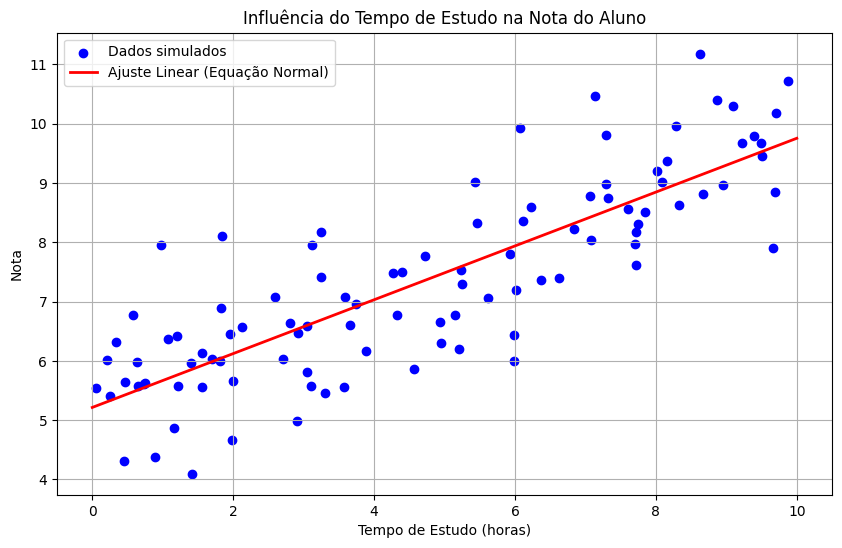

In [5]:
# Geração de pontos para traçar a linha de regressão
line_x = np.array([[0], [10]])
line_x_b = np.c_[np.ones((2, 1)), line_x]
line_y = line_x_b.dot(theta_best)

# Plot dos dados e da linha de regressão
plt.figure(figsize=(10, 6))
plt.scatter(tempo_de_estudo, notas, color='blue', label='Dados simulados')
plt.plot(line_x, line_y, color='red', linewidth=2, label='Ajuste Linear (Equação Normal)')
plt.xlabel('Tempo de Estudo (horas)')
plt.ylabel('Nota')
plt.title('Influência do Tempo de Estudo na Nota do Aluno')
plt.legend()
plt.grid(True)
plt.show()

### 3.2. Passo 4: Predição de notas com o modelo

O modelo é utilizado para prever as notas de dois novos alunos hipotéticos: um que não estudou (0 horas) e outro que estudou o tempo máximo (10 horas).

In [6]:
# Criação de novas instâncias para predição
X_new = np.array([[0], [10]])
X_new_b = np.c_[np.ones((2, 1)), X_new]

# Realização das predições
notas_previstas = X_new_b.dot(theta_best)

print(f"Nota prevista para 0 horas de estudo: {notas_previstas[0][0]:.2f}")
print(f"Nota prevista para 10 horas de estudo: {notas_previstas[1][0]:.2f}")

Nota prevista para 0 horas de estudo: 5.22
Nota prevista para 10 horas de estudo: 9.76


## 4. CONCLUSÃO

Este notebook demonstrou o processo de implementação de um modelo de regressão linear através da solução analítica da Equação Normal. Foi possível observar como os coeficientes do modelo são calculados diretamente a partir dos dados e, subsequentemente, utilizados para realizar predições. A visualização gráfica confirmou que a linha de regressão se ajustou adequadamente à tendência dos dados simulados, validando a eficácia do método para este problema.